In [1]:
import pandas as pd
from matplotlib import pyplot as plt
import numpy as np


In [2]:
df = pd.read_csv("Mall_Customers.csv")
df

,CustomerID,Gender,Age,Annual Income (k$),Spending Score (1-100)
0,1,Male,19,15,39
1,2,Male,21,15,81
2,3,Female,20,16,6
3,4,Female,23,16,77
4,5,Female,31,17,40
...,...,...,...,...,...
195,196,Female,35,120,79
196,197,Female,45,126,28
197,198,Male,32,126,74
198,199,Male,32,137,18


In [3]:
df.replace({
    "Male":0,
    "Female":1
}, inplace=True)

C:\Users\Sugeshan\AppData\Local\Temp\ipykernel_22920\1052228999.py:1: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df.replace({


In [4]:
df

,CustomerID,Gender,Age,Annual Income (k$),Spending Score (1-100)
0,1,0,19,15,39
1,2,0,21,15,81
2,3,1,20,16,6
3,4,1,23,16,77
4,5,1,31,17,40
...,...,...,...,...,...
195,196,1,35,120,79
196,197,1,45,126,28
197,198,0,32,126,74
198,199,0,32,137,18


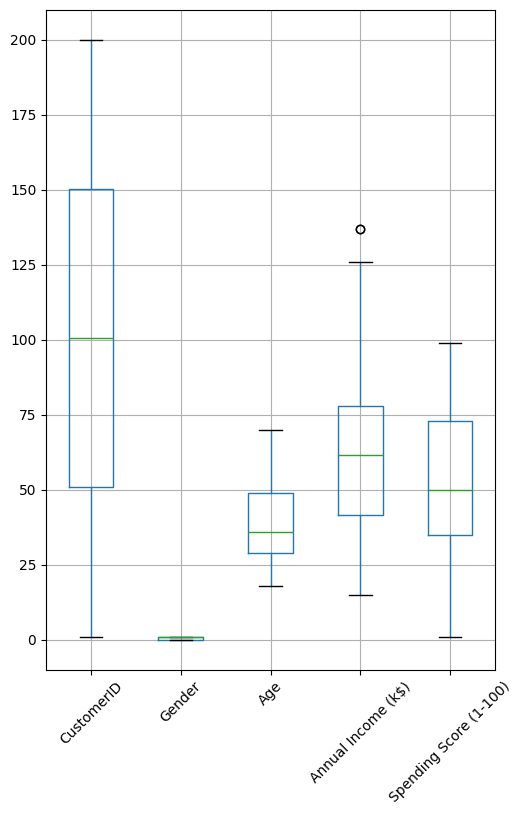

In [17]:

plt.figure(figsize=(15,15))
plt.subplot(2,3,1)
df.boxplot()
plt.xticks(rotation = 45)
plt.tight_layout()
plt.show()

In [22]:
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler

x = df.drop("Spending Score (1-100)", axis=1)
y = df['Spending Score (1-100)']

x_scale = StandardScaler()
std = x_scale.fit_transform(x)

model = KMeans(n_clusters=5, random_state=42)
model.fit(std)

y_pred = model.predict(std)
print(y_pred)

[3 3 2 2 2 2 2 2 0 2 0 2 0 2 3 3 2 3 0 2 3 3 2 3 0 3 2 3 2 2 0 2 0 3 2 2 2
 2 2 2 0 3 0 2 0 2 0 2 2 2 0 3 2 0 0 0 0 0 2 0 0 3 0 0 0 3 2 0 3 2 0 0 0 0
 0 3 0 3 2 0 0 3 0 0 2 0 0 2 1 0 0 3 0 1 1 3 1 1 0 3 1 1 0 3 0 1 0 0 0 0 0
 1 1 3 1 1 0 1 1 1 4 1 1 4 1 1 4 4 0 4 4 4 1 1 4 1 1 4 4 1 1 4 1 1 4 4 4 1
 1 4 4 4 1 1 1 1 4 1 4 1 1 1 4 1 4 1 4 1 1 4 4 4 4 4 1 1 4 4 4 4 1 1 4 1 1
 4 1 4 1 1 1 1 4 1 1 1 1 4 4 4]


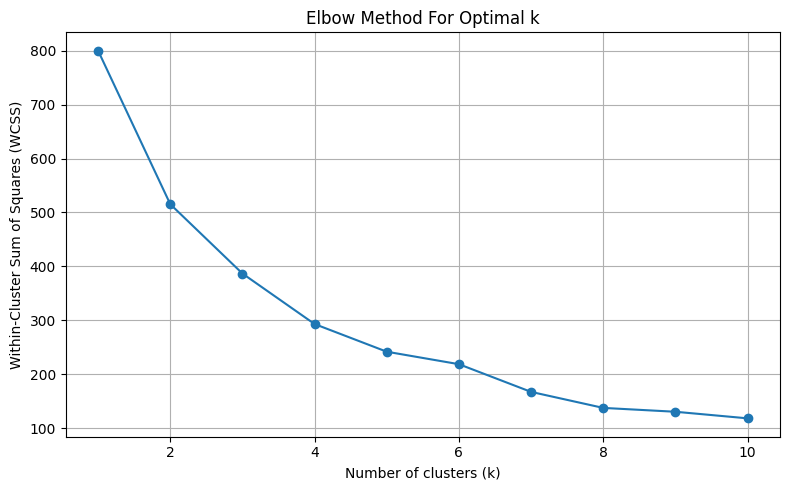

In [ ]:
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler


X = df.drop("Spending Score (1-100)", axis=1)
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)


wcss = []
K_range = range(1, 11)

for k in K_range:
    kmeans = KMeans(n_clusters=k, random_state=42)
    kmeans.fit(X_scaled)
    wcss.append(kmeans.inertia_)  

plt.figure(figsize=(8, 5))
plt.plot(K_range, wcss, marker='o')
plt.title('Elbow Method For Optimal k')
plt.xlabel('Number of clusters (k)')
plt.ylabel('Within-Cluster Sum of Squares (WCSS)')
plt.grid(True)
plt.tight_layout()
plt.show()


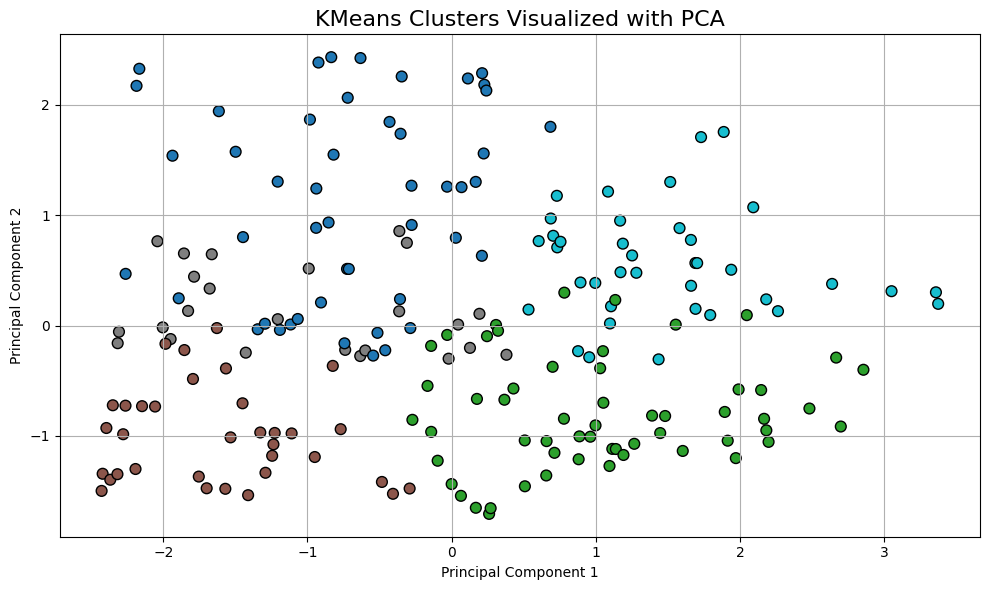

Silhouette Score for k=5: 0.3704


In [24]:
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.metrics import silhouette_score
import matplotlib.pyplot as plt

# 1. Prepare data
X = df.drop("Spending Score (1-100)", axis=1)
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# 2. Fit KMeans
kmeans = KMeans(n_clusters=5, random_state=42)
cluster_labels = kmeans.fit_predict(X_scaled)
df['Cluster'] = cluster_labels

# 3. PCA for 2D visualization
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)

# 4. Plot color-coded clusters
plt.figure(figsize=(10, 6))
scatter = plt.scatter(X_pca[:, 0], X_pca[:, 1], c=cluster_labels, cmap='tab10', s=60, edgecolor='k')
plt.title("KMeans Clusters Visualized with PCA", fontsize=16)
plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")
plt.grid(True)
plt.tight_layout()
plt.show()

# 5. Evaluate with Silhouette Score
sil_score = silhouette_score(X_scaled, cluster_labels)
print(f"Silhouette Score for k=5: {sil_score:.4f}")
